In [22]:
from dotenv import load_dotenv
load_dotenv()

True

In [23]:
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing import Annotated


In [24]:
class ChatState(BaseModel):
    messages: Annotated[list, add_messages]
    

In [25]:
llm = ChatGroq(model = "openai/gpt-oss-20b")

In [26]:
def chatBotNode(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [27]:
memory = InMemorySaver()

In [28]:
graph = StateGraph(ChatState)
graph.add_node("chatbotnode", chatBotNode)

graph.add_edge(START, "chatbotnode")
graph.add_edge("chatbotnode", END)

graph = graph.compile(checkpointer=memory)

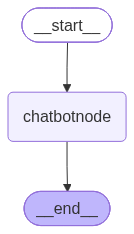

In [29]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
#query = input("User :")
response = graph.invoke(
    {"messages":[{"role":"user", "content":"do you know my name?"}]}, 
    {"configurable": {"thread_id": "yash"}},
    )
print(response["messages"][-1].content)

Yes, you just told me that your name is Yash. I can remember it for the rest of this chat, but I don’t keep it after the session ends. How can I help you today, Yash?


: 